<a href="https://colab.research.google.com/github/pranacollab/prana-sentinel/blob/main/notebooks/prana_sentinel_poc_01_dengue_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook pulls and explores Dengue fever cases in Brasil.
# Prana Sentinel — PoC Phase 1
## Dengue Case Data Exploration (Brazil)
### Data Source: InfoDengue API
### Date: March 2026

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas requests matplotlib seaborn

import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Pull dengue data for Rio de Janeiro (geocode 3304557)
# We'll start with one city to keep it manageable

url = "https://info.dengue.mat.br/api/alertcity"

params = {
    "geocode": 3304557,       # Rio de Janeiro
    "disease": "dengue",
    "format": "json",
    "ew_start": 1,            # Epidemiological week start
    "ew_end": 52,
    "ey_start": 2022,
    "ey_end": 2023
}

response = requests.get(url, params=params)
data = response.json()
df = pd.DataFrame(data)

print(df.shape)
print(df.head())

(104, 31)
      data_iniSE      SE  casos_est  casos_est_min  casos_est_max  casos  \
0  1703376000000  202352     1198.0           1198           1198   1198   
1  1702771200000  202351     1098.0           1098           1098   1098   
2  1702166400000  202350     1411.0           1411           1411   1411   
3  1701561600000  202349     1149.0           1149           1149   1149   
4  1700956800000  202348      983.0            983            983    983   

      p_rt1  p_inc100k  Localidade_id  nivel  ...           umidmed  \
0  0.268316  18.080702              0      4  ...  71.2181428571429   
1  0.145074  16.571460              0      4  ...  74.3208857142857   
2  1.000000  21.295383              0      4  ...  76.1185428571429   
3  1.000000  17.341173              0      4  ...  79.2977142857143   
4  1.000000  14.835835              0      4  ...  77.6062571428571   

            umidmin           tempmed           tempmax  casprov casprov_est  \
0  53.9967142857143  27.06

['data_iniSE', 'SE', 'casos_est', 'casos_est_min', 'casos_est_max', 'casos', 'p_rt1', 'p_inc100k', 'Localidade_id', 'nivel', 'id', 'versao_modelo', 'municipio_nome', 'tweet', 'Rt', 'pop', 'tempmin', 'umidmax', 'receptivo', 'transmissao', 'nivel_inc', 'umidmed', 'umidmin', 'tempmed', 'tempmax', 'casprov', 'casprov_est', 'casprov_est_min', 'casprov_est_max', 'casconf', 'notif_accum_year']
         data_iniSE             SE    casos_est  casos_est_min  casos_est_max  \
count  1.040000e+02     104.000000   104.000000     104.000000     104.000000   
mean   1.672229e+12  202276.500000   517.067308     517.067308     517.067308   
std    1.824452e+10      52.456732   503.354442     503.354442     503.354442   
min    1.641082e+12  202201.000000    14.000000      14.000000      14.000000   
25%    1.656655e+12  202226.750000   128.250000     128.250000     128.250000   
50%    1.672229e+12  202276.500000   357.000000     357.000000     357.000000   
75%    1.687802e+12  202326.250000   720.50

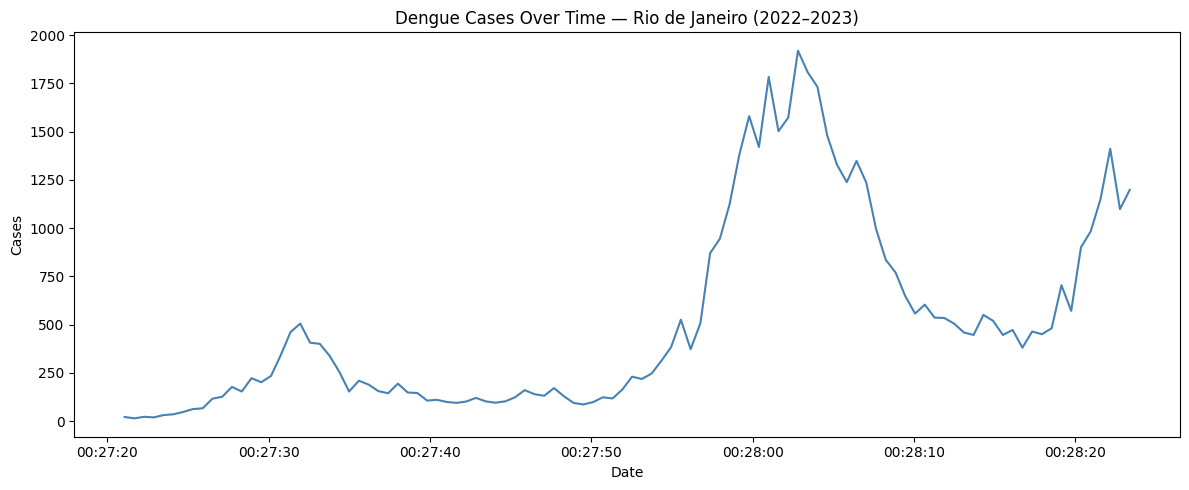

In [ ]:
# Check what columns we have
print(df.columns.tolist())

# Summary statistics
print(df.describe())

# Plot cases over time
df['data_iniSE'] = pd.to_datetime(df['data_iniSE'])
df = df.sort_values('data_iniSE')

plt.figure(figsize=(12, 5))
plt.plot(df['data_iniSE'], df['casos'], color='steelblue')
plt.title('Dengue Cases Over Time — Rio de Janeiro (2022–2023)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.tight_layout()
plt.show()

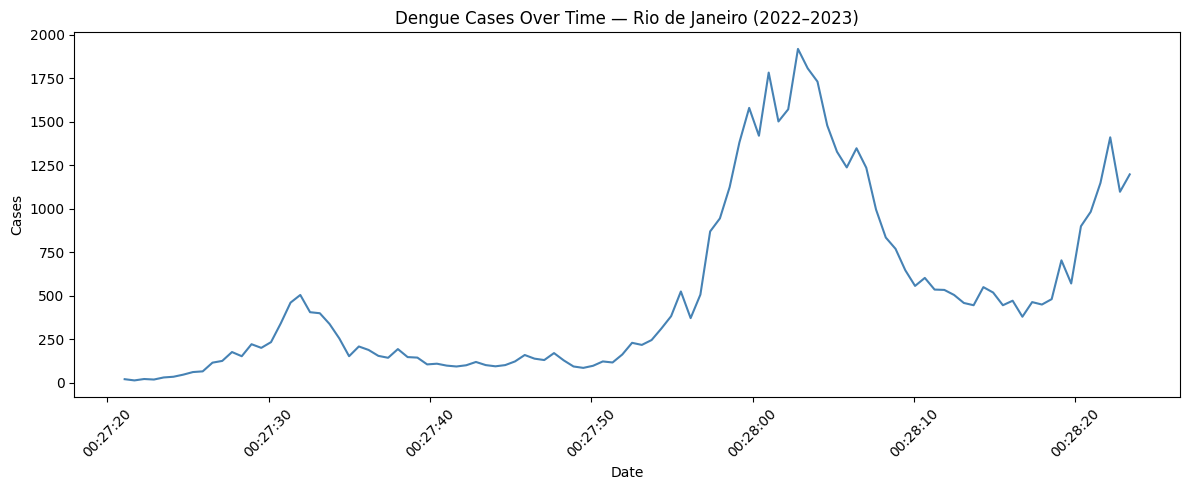

In [ ]:
# Fix the date parsing
df['data_iniSE'] = pd.to_datetime(df['data_iniSE'], unit='ms')
df = df.sort_values('data_iniSE')

plt.figure(figsize=(12, 5))
plt.plot(df['data_iniSE'], df['casos'], color='steelblue')
plt.title('Dengue Cases Over Time — Rio de Janeiro (2022–2023)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Let's inspect the raw date column before any conversion
print(df['data_iniSE'].dtype)
print(df['data_iniSE'].head(10))

datetime64[ns]
103   1970-01-01 00:27:21.081600
102   1970-01-01 00:27:21.686400
101   1970-01-01 00:27:22.291200
100   1970-01-01 00:27:22.896000
99    1970-01-01 00:27:23.500800
98    1970-01-01 00:27:24.105600
97    1970-01-01 00:27:24.710400
96    1970-01-01 00:27:25.315200
95    1970-01-01 00:27:25.920000
94    1970-01-01 00:27:26.524800
Name: data_iniSE, dtype: datetime64[ns]


In [ ]:
# Re-pull the raw data without any date conversion first
response = requests.get(url, params=params)
data = response.json()
df_raw = pd.DataFrame(data)

# Check what the raw value actually looks like before conversion
print(df_raw['data_iniSE'].head(5))
print(type(df_raw['data_iniSE'][0]))

0    1703376000000
1    1702771200000
2    1702166400000
3    1701561600000
4    1700956800000
Name: data_iniSE, dtype: int64
<class 'numpy.int64'>


103   2022-01-02
102   2022-01-09
101   2022-01-16
100   2022-01-23
99    2022-01-30
Name: data_iniSE, dtype: datetime64[ns]


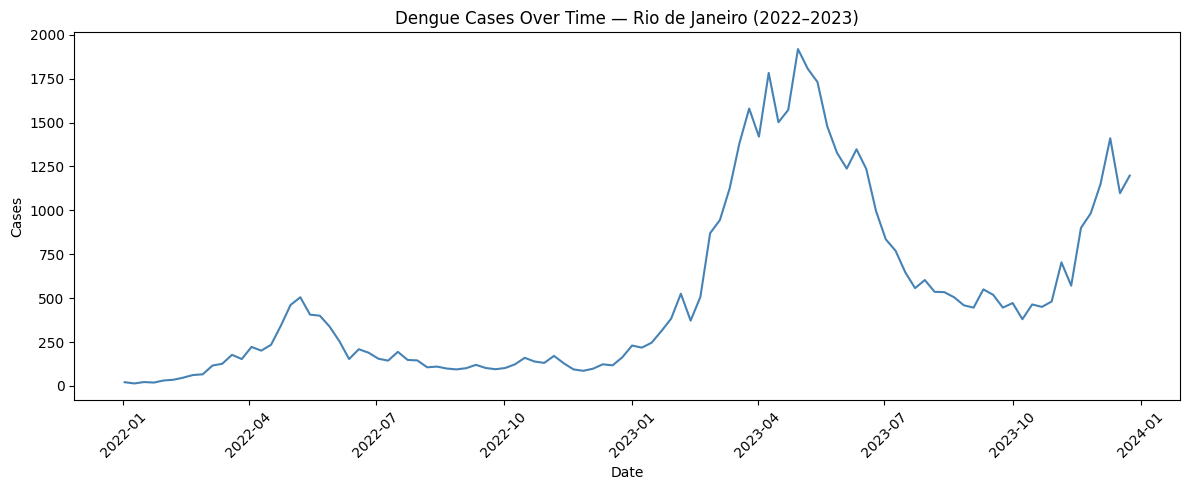

In [ ]:
# Convert millisecond timestamps correctly
df_raw['data_iniSE'] = pd.to_datetime(df_raw['data_iniSE'], unit='ms')
df_raw = df_raw.sort_values('data_iniSE')

# Verify the conversion worked
print(df_raw['data_iniSE'].head(5))

# Plot with corrected dates
plt.figure(figsize=(12, 5))
plt.plot(df_raw['data_iniSE'], df_raw['casos'], color='steelblue')
plt.title('Dengue Cases Over Time — Rio de Janeiro (2022–2023)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save to Google Drive
df_raw.to_csv('/content/drive/MyDrive/prana_sentinel_poc_01_dengue_rio.csv', index=False)
print("Saved successfully!")

Saved successfully!


##End of notebook notes:
This seasonal pattern — peaking in the Brazilian summer/rainy season (January–May) and dropping in the dry months — is exactly the kind of signal a prediction model can learn from.

## Notes on the code:
we encountered issues with the x-axis where timestamps were being used vs dates. Reviewed output before pandas conversion "those are millisecond Unix timestamps, which means the original unit='ms' fix was right, but something else overrode it. Run this clean version from scratch in a new cell.  The key difference here is we're working from df_raw — the unmodified dataframe — rather than df which already had a bad conversion applied to it. The print statement will confirm the dates look right before the chart renders.